In [15]:
import os 
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt



In [54]:
def get_chunk_actions(states, horizon, traj_lengths, normalize=False):
    def _ep_actions(ep_states, horizon):
        ep_actions = []
        indices = np.arange(0, len(ep_states)-horizon+1, dtype=int)
        for index in indices:
            meta_pose = ep_states[index]
            future_poses = ep_states[index+1:index+horizon+1]
            actions = future_poses - meta_pose 
            # replace gripper with absolute gripper width 
            actions[:, -1] = future_poses[:, -1]
            paddings = horizon - len(actions)
            if paddings > 0:
                padded = np.concatenate([actions[-1:]] * paddings)
                actions = np.concatenate([actions, padded])
            ep_actions.append(actions)
        return np.array(ep_actions)
    ep_start = 0
    ep_actions, all_actions = [], []
    for traj_length in traj_lengths:
        ep_states = states[ep_start: ep_start + traj_length]
        out = _ep_actions(ep_states, horizon)
        ep_actions.append( out )
        ep_start += traj_length
        if len(all_actions) == 0:
            all_actions = out
        else:
            all_actions = np.concatenate([all_actions, out])
    if normalize:
        all_actions = all_actions.reshape(-1, all_actions.shape[-1])
        max_, min_ = all_actions.max(0), all_actions.min(0)
        
    means, stds = [], []
    for ep_action in ep_actions:
        ep_action = ep_action.reshape(-1, ep_action.shape[-1])
        if normalize:
            ep_action = 2 * (ep_action - min_) / (max_ - min_) - 1
        means.append( ep_action[:, :7].mean(0)); stds.append(ep_action[:, :7].std(0))
    return means, stds

In [55]:
max_n_episodes=1000
horizon_steps = 8
dataset_path = '/zfsauton/scratch/yiqiw2/100%/datasets/ethernet_unplug_red'

state_path = os.path.join(dataset_path, 'states.npz')
dataset = np.load(state_path, allow_pickle=False)  # only np arrays
traj_lengths = dataset["traj_length"][:max_n_episodes]  # 1-D array
total_num_steps = np.sum(traj_lengths)

states = np.concatenate([dataset['pose'], dataset['gripper_width'][:, None] ], axis = -1)



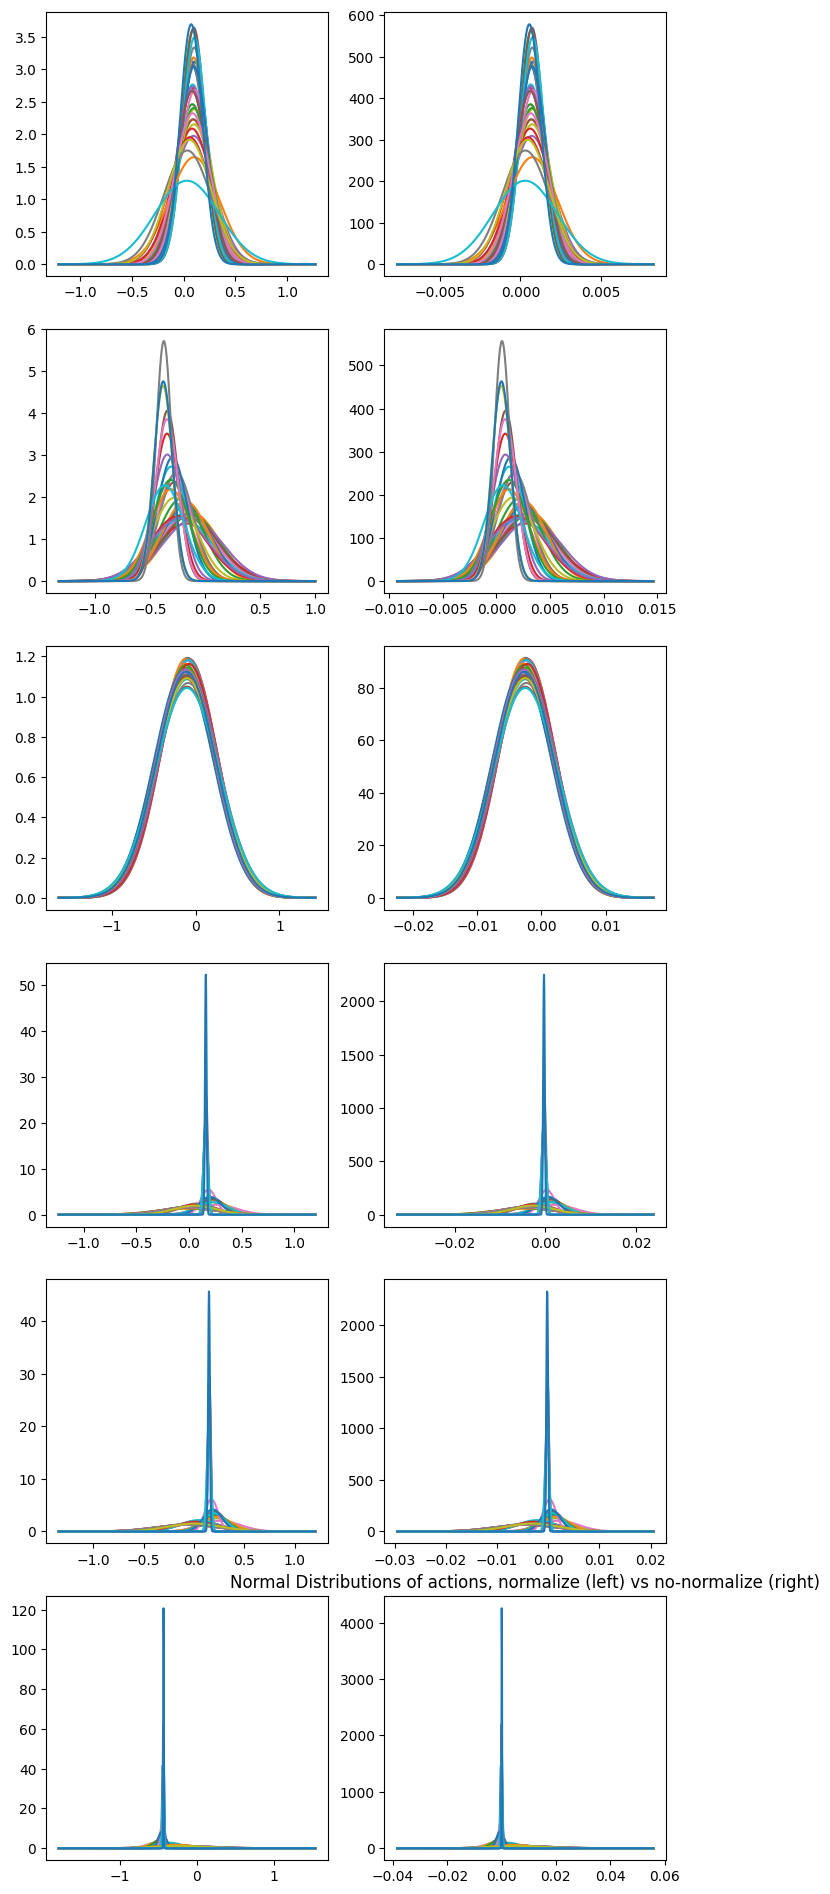

In [ ]:

N=6

means, stds = get_chunk_actions(states, horizon_steps, traj_lengths, normalize=True)
means_, stds_ = get_chunk_actions(states, horizon_steps, traj_lengths, normalize=False)
fig, axes = plt.subplots(figsize=(8, N*4), nrows=N, ncols=2)

for ax in range(N):
    
    # List of (mean, std)
    params = [ (m, s) for m,s in zip(np.array(means)[:, ax], np.array(stds)[:, ax])]
    params_ = [ (m, s) for m,s in zip(np.array(means_)[:, ax], np.array(stds_)[:, ax])]
    # Determine a reasonable x-range covering all distributions
    xmin = min(mu - 4 * sigma for mu, sigma in params)
    xmax = max(mu + 4 * sigma for mu, sigma in params)
    xmin_ = min(mu - 4 * sigma for mu, sigma in params_)
    xmax_ = max(mu + 4 * sigma for mu, sigma in params_)

    x = np.linspace(xmin, xmax, 1000)
    for i, (mu, sigma) in enumerate(params):
        y = norm.pdf(x, loc=mu, scale=sigma)
        axes[ax][0].plot(x, y)
    x = np.linspace(xmin_, xmax_, 1000)
    for i, (mu, sigma) in enumerate(params_):
        y = norm.pdf(x, loc=mu, scale=sigma)
        axes[ax][1].plot(x, y)



None
